# 04. Visualización de Datos

### Dataset bancario limpio

**Objetivo de este notebook:** presentar las gráficas más relevantes del dataset ya limpio y analizado (`dataset_bancario_limpio.xlsx`), para mostrar de forma clara y visual los hallazgos clave del proyecto.

**Criterio de selección:** en lugar de graficar todo lo posible, se eligieron 7 gráficas que en conjunto cubren:

1. Estructura general del flujo de dinero (ingresos vs egresos)
2. Salud del proceso de conciliación bancaria
3. Concentración de problemas por banco
4. Distribución del dinero por categoría de movimiento
5. Comportamiento de mora por empresa
6. Evolución del negocio en el tiempo
7. Cruce banco vs estado de conciliación

Cada gráfica va acompañada de una celda de **instrucción** (qué se va a graficar y por qué) y una celda de **insight** con la lectura de resultados.

# 1. Carga de librerías y del dataset limpio

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual general
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [3]:
# Cargar el dataset limpio
df = pd.read_excel("dataset_bancario_limpio.xlsx")

# Columna auxiliar de mes, necesaria para la gráfica de evolución mensual
df["mes"] = df["fecha_operacion"].dt.to_period("M").astype(str)

df.shape

(150, 34)

## 2. Ingresos vs Egresos

**Instrucción:** contar cuántos movimientos hay de cada tipo (`Ingreso` / `Egreso`) para ver la estructura general del flujo de dinero de las empresas.

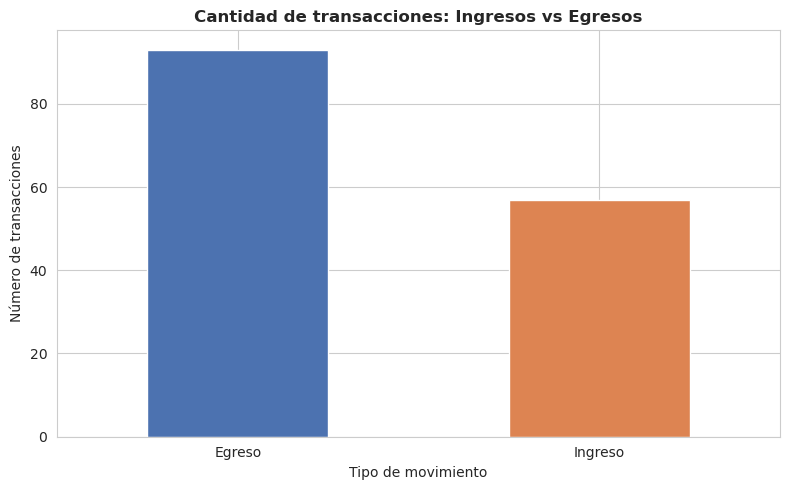

In [5]:
ax = df["tipo_movimiento"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Cantidad de transacciones: Ingresos vs Egresos")
ax.set_xlabel("Tipo de movimiento")
ax.set_ylabel("Número de transacciones")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** el dataset tiene más movimientos de egreso que de ingreso, lo cual es esperable en la operación diaria de una empresa (pagos a proveedores, nómina, impuestos, comisiones, etc.), mientras que los ingresos se concentran en menos transacciones pero de mayor valor (ventas, créditos).

## 3. Transacciones por Estado de Conciliación

**Instrucción:** visualizar en cuántas transacciones el estado es `Conciliado`, `Pendiente`, `Diferencia`, `Rechazado` o `Duplicado`. Esto permite medir qué tan sano está el proceso bancario.

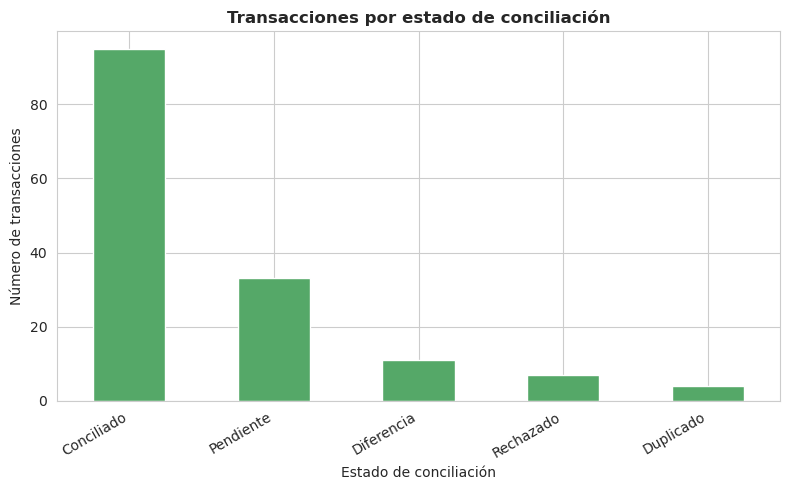

In [6]:
orden_estados = df["estado_conciliacion"].value_counts().index

ax = df["estado_conciliacion"].value_counts().plot(kind="bar", color="#55A868")
ax.set_title("Transacciones por estado de conciliación")
ax.set_xlabel("Estado de conciliación")
ax.set_ylabel("Número de transacciones")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Insight:** la mayoría de las transacciones están conciliadas, lo que indica un proceso bancario relativamente saludable. Sin embargo, existe un grupo considerable de transacciones `Pendiente`, `Diferencia` y `Rechazado` que representan focos de atención para el equipo financiero.

## 4. Problemas de Conciliación por Banco

**Instrucción:** de las transacciones con estado `Pendiente`, `Diferencia` o `Rechazado`, ver cómo se distribuyen entre los distintos bancos. Esto ayuda a identificar si algún banco concentra más problemas operativos que los demás.

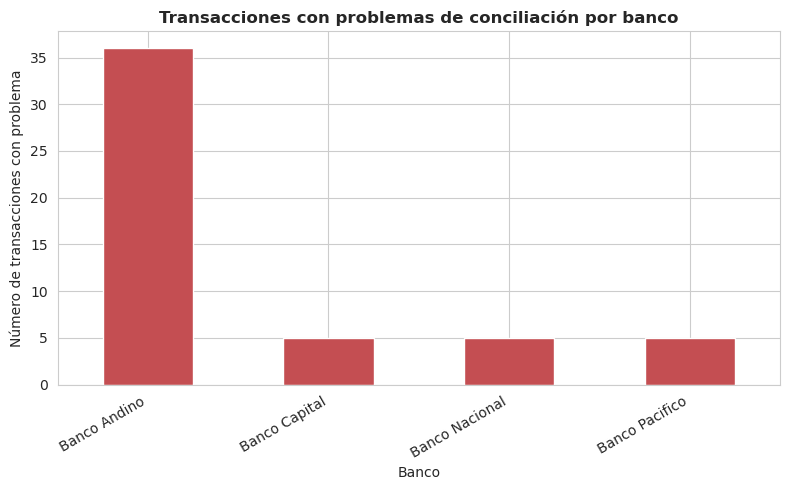

In [8]:
problemas = df[df["estado_conciliacion"].isin(["Pendiente", "Diferencia", "Rechazado"])]

ax = problemas["banco"].value_counts().plot(kind="bar", color="#C44E52")
ax.set_title("Transacciones con problemas de conciliación por banco")
ax.set_xlabel("Banco")
ax.set_ylabel("Número de transacciones con problema")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Insight:** aunque los 4 bancos manejan un volumen de transacciones muy similar, no todos concentran la misma cantidad de problemas de conciliación. Esto permite priorizar la revisión operativa con el banco que presenta más incidencias.

## 5. Valor Total por Categoría

**Instrucción:** sumar el `valor_neto` agrupado por categoría de movimiento, para identificar en qué conceptos se mueve más dinero dentro de la operación.

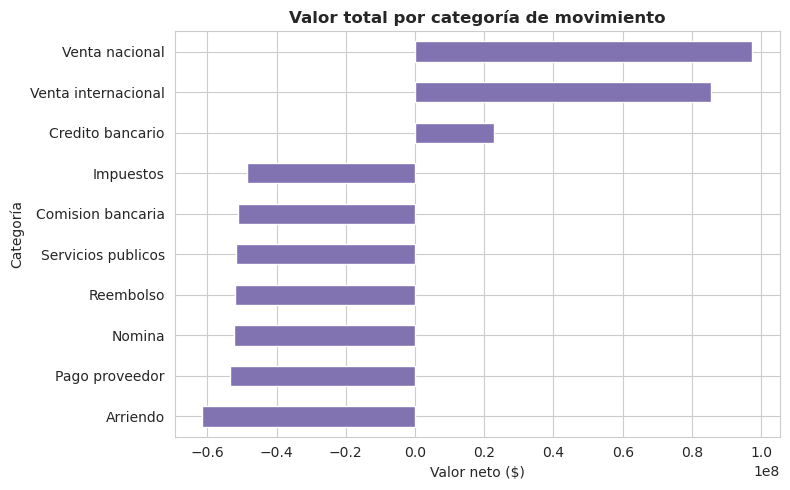

In [9]:
valor_categoria = df.groupby("categoria")["valor_neto"].sum().sort_values()

ax = valor_categoria.plot(kind="barh", color="#8172B2")
ax.set_title("Valor total por categoría de movimiento")
ax.set_xlabel("Valor neto ($)")
ax.set_ylabel("Categoría")
plt.tight_layout()
plt.show()

**Insight:** el crédito bancario y las ventas (nacionales e internacionales) concentran los mayores montos, mientras que categorías como comisiones bancarias o arriendo, aunque frecuentes, representan un peso económico mucho menor.

## 6. Mora Promedio por Empresa

**Instrucción:** calcular el promedio de `dias_mora` por empresa, para identificar cuál presenta más retrasos en sus pagos u obligaciones.

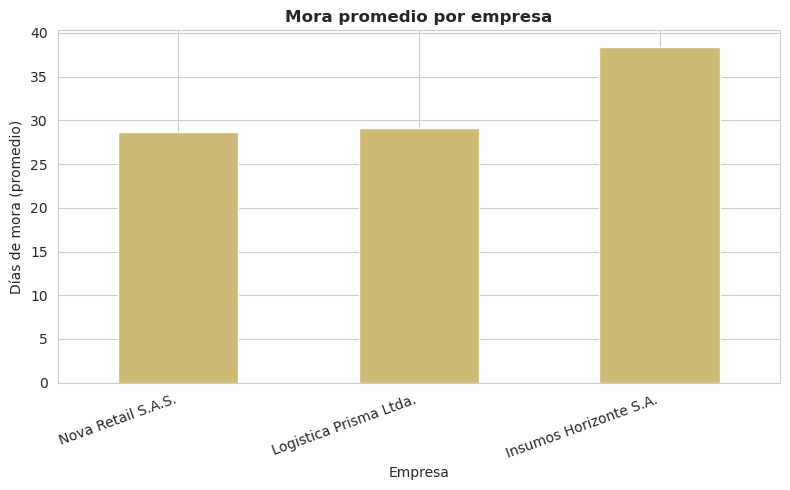

In [11]:
mora_empresa = df.groupby("empresa")["dias_mora"].mean().sort_values()

ax = mora_empresa.plot(kind="bar", color="#CCB974")
ax.set_title("Mora promedio por empresa")
ax.set_xlabel("Empresa")
ax.set_ylabel("Días de mora (promedio)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Insight:** no todas las empresas presentan el mismo comportamiento de mora. La empresa con el promedio más alto es candidata a un seguimiento más cercano o a una revisión de sus condiciones de pago.

## 7. Evolución Mensual del Valor Neto

**Instrucción:** sumar el `valor_neto` por mes, usando la fecha de operación, para ver cómo evoluciona el movimiento de dinero a lo largo del tiempo.

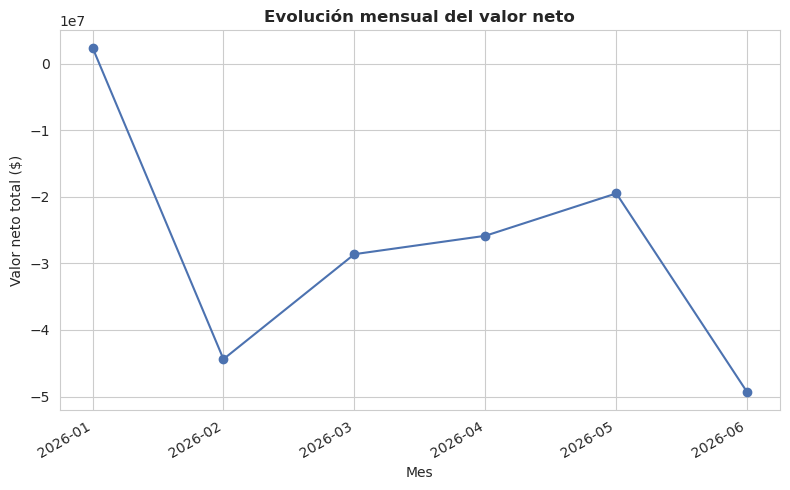

In [12]:
evolucion_mensual = df.groupby("mes")["valor_neto"].sum()

ax = evolucion_mensual.plot(kind="line", marker="o", color="#4C72B0")
ax.set_title("Evolución mensual del valor neto")
ax.set_xlabel("Mes")
ax.set_ylabel("Valor neto total ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Insight:** el valor neto muestra variaciones mes a mes, lo cual es normal en operaciones empresariales, pero permite detectar meses atípicos (picos o caídas) que valdría la pena investigar con más detalle.

## 8. Cruce Banco vs Estado de Conciliación

**Instrucción:** construir una tabla cruzada (`crosstab`) entre banco y estado de conciliación, y visualizarla como heatmap. Esto combina en una sola gráfica la información de las secciones 3 y 4.

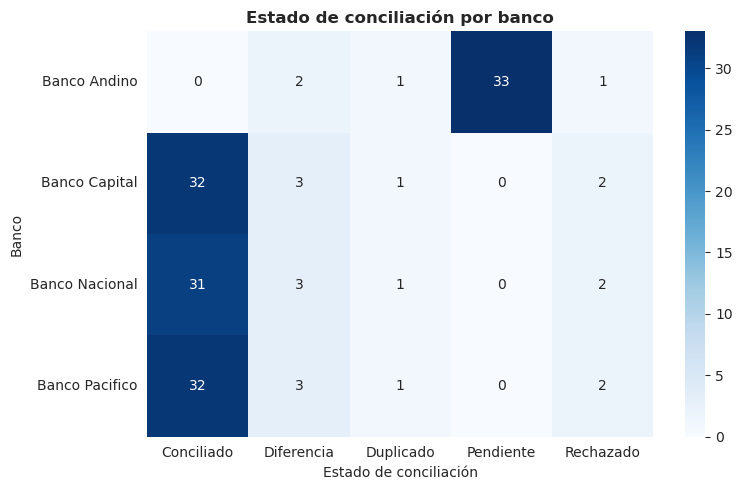

In [13]:
tabla_banco_estado = pd.crosstab(df["banco"], df["estado_conciliacion"])

plt.figure(figsize=(8, 5))
sns.heatmap(tabla_banco_estado, annot=True, fmt="d", cmap="Blues")
plt.title("Estado de conciliación por banco")
plt.xlabel("Estado de conciliación")
plt.ylabel("Banco")
plt.tight_layout()
plt.show()

**Insight:** el heatmap permite ver de un vistazo qué banco concentra más casos `Conciliado` y cuáles concentran más `Pendiente`, `Diferencia` o `Rechazado`, cruzando en una sola imagen la información de volumen y de calidad del proceso.

## 9. Conclusiones del Notebook

- El flujo de dinero está dominado por egresos en número de transacciones, pero los ingresos representan montos individuales más altos (créditos y ventas).
- El proceso de conciliación es mayormente saludable, aunque existe un grupo de transacciones pendientes/con diferencia/rechazadas que merece seguimiento.
- Los problemas de conciliación no se distribuyen igual entre bancos, lo que permite priorizar la gestión operativa.
- El crédito bancario y las ventas son las categorías que más dinero mueven.
- La mora varía por empresa, identificando posibles focos de riesgo de cartera.
- La evolución mensual del valor neto muestra el comportamiento del negocio en el tiempo, útil para detectar estacionalidad o anomalías.